In [9]:
# Package dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

[*********************100%***********************]  1 of 1 completed


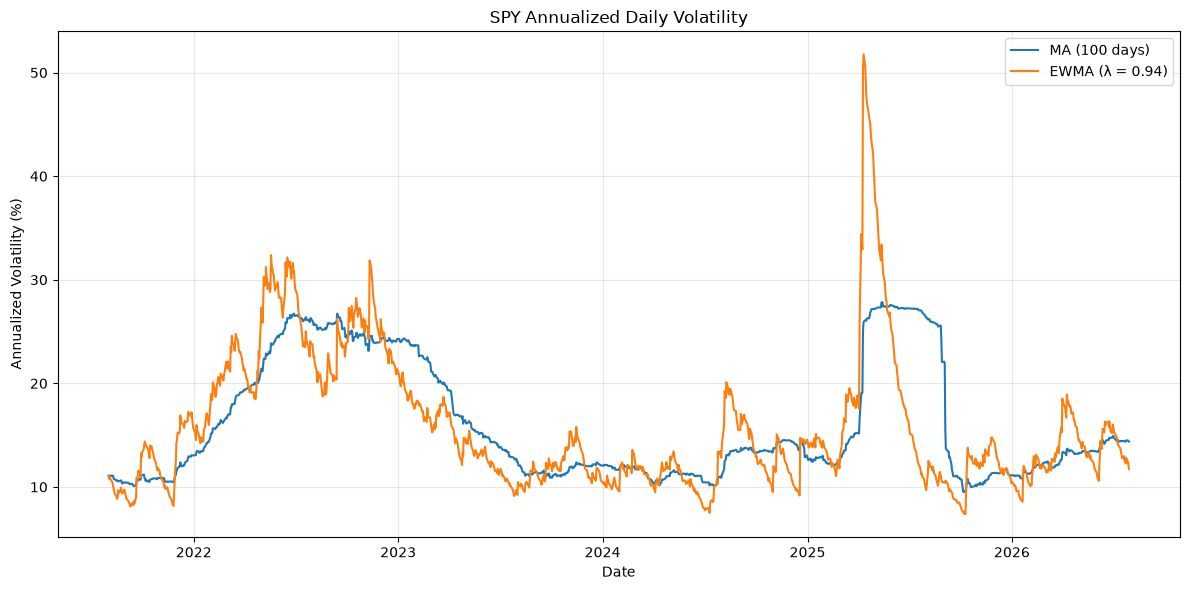

In [8]:
#Q1
# define the parameters
symbol = "SPY"
download_start_date = "2021-01-01"
start_date = "2021-08-01"
end_date = "2026-07-30"
n = 100
lam = 0.94
delta = 1/252

# Download SPY daily closing prices from Yahoo Finance
spy_data = yf.download(symbol, start=download_start_date, end=end_date)

close_prices = spy_data['Close'].squeeze()  

# Calculate daily log returns
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()

# (a) Moving Average (MA) Volatility
ma_daily_vol = log_returns.rolling(window=n).std(ddof=0).shift(1)
ma_annual_vol = ma_daily_vol * np.sqrt(1/delta)

#(b) EWMA Volatility
first_idx = log_returns.index.searchsorted(pd.Timestamp(start_date))

initial_returns = log_returns.iloc[first_idx-n:first_idx]
initial_var = initial_returns.var(ddof=0)

ewma_var = pd.Series(index=log_returns.index, dtype=float)
ewma_var.iloc[first_idx] = initial_var

for i in range(first_idx + 1, len(log_returns)):
    ewma_var.iloc[i] = (
        lam * ewma_var.iloc[i - 1]
        + (1 - lam) * log_returns.iloc[i - 1] ** 2
    )

ewma_annual_vol = np.sqrt(ewma_var) * np.sqrt(1/delta)

# Prep data for plotting
ma_plot = ma_annual_vol.loc[start_date:end_date]
ewma_plot = ewma_annual_vol.loc[start_date:end_date]

# Plotting the results
plt.figure(figsize=(12, 6))

plt.plot(
    ma_plot.index,
    ma_plot * 100,
    label="MA (100 days)"
)

plt.plot(
    ewma_plot.index,
    ewma_plot * 100,
    label="EWMA (λ = 0.94)"
)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility (%)")
plt.title("SPY Annualized Daily Volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
# Use closing prices from 06/01/2025 to 05/31/2026
fit_close = close_prices.loc["2025-06-01":"2026-05-31"]
fit_returns = np.log(fit_close / fit_close.shift(1)).dropna().to_numpy()

# Fixed initial variance
initial_var = np.var(fit_returns, ddof=0)

# Gaussian negative log-likelihood for GARCH(1,1)
def garch_nll(params):
    alpha0, alpha1, beta1 = params

    # Enforce GARCH parameter conditions
    if alpha0 <= 0 or alpha1 < 0 or beta1 < 0 or alpha1 + beta1 >= 1:
        return np.inf

    sigma2 = np.empty(len(fit_returns))
    sigma2[0] = initial_var

    # Recursively estimate conditional variance
    for i in range(1, len(fit_returns)):
        sigma2[i] = (
            alpha0
            + alpha1 * fit_returns[i - 1]**2
            + beta1 * sigma2[i - 1]
        )

    return np.sum(np.log(sigma2) + fit_returns**2 / sigma2)

# Fit GARCH parameters by minimizing negative log-likelihood
result = minimize(
    garch_nll,
    [initial_var * 0.05, 0.05, 0.90],
    method="Nelder-Mead"
)

alpha0, alpha1, beta1 = result.x

print(f"alpha0 = {alpha0:.10f}")
print(f"alpha1 = {alpha1:.6f}")
print(f"beta1  = {beta1:.6f}")

alpha0 = 0.0000068945
alpha1 = 0.054364
beta1  = 0.824566


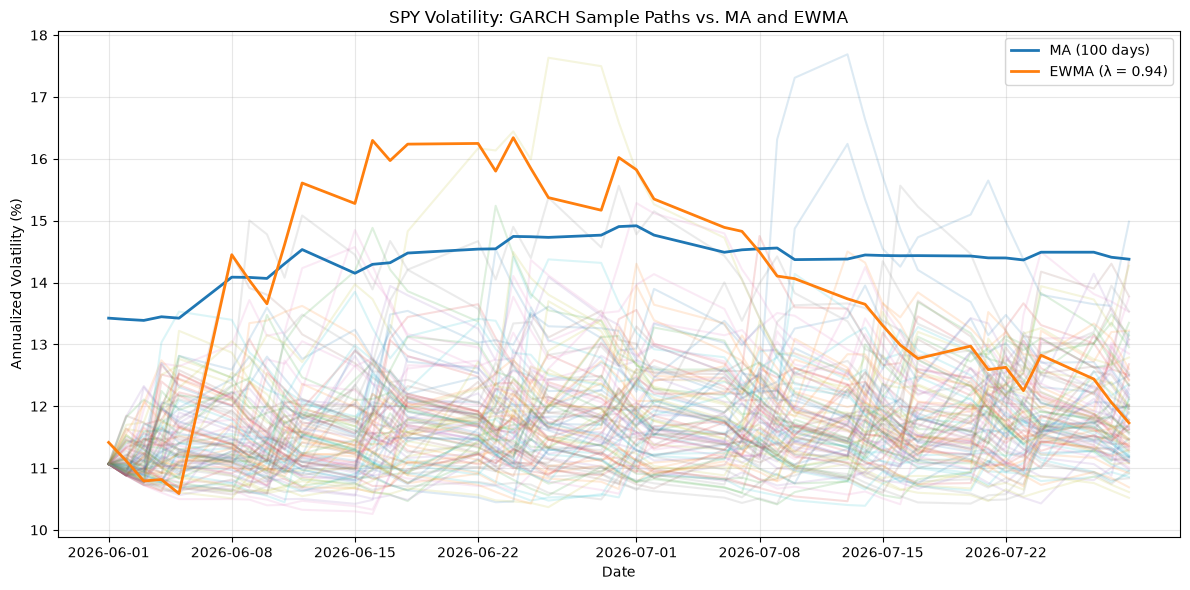

In [11]:
# Q3
M = 100
forecast_start = "2026-06-01"
forecast_end = "2026-07-30"

# Trading days in the forecast period
forecast_dates = close_prices.loc[forecast_start:forecast_end].index
N = len(forecast_dates)

# Reconstruct fitted GARCH variance over the Q2 fitting sample
sigma2_fit = np.empty(len(fit_returns))
sigma2_fit[0] = initial_var

for i in range(1, len(fit_returns)):
    sigma2_fit[i] = (
        alpha0
        + alpha1 * fit_returns[i - 1]**2
        + beta1 * sigma2_fit[i - 1]
    )

# One-day-ahead variance forecast for the first forecast date
first_forecast_var = (
    alpha0
    + alpha1 * fit_returns[-1]**2
    + beta1 * sigma2_fit[-1]
)

# Simulate M GARCH volatility paths
garch_paths = np.empty((M, N))

np.random.seed(42)

for m in range(M):
    sigma2 = first_forecast_var

    for j in range(N):
        # Record annualized volatility for this day
        garch_paths[m, j] = np.sqrt(sigma2) * np.sqrt(252)

        # Simulate this day's return
        z = np.random.normal()
        x = np.sqrt(sigma2) * z

        # Update next day's variance
        sigma2 = (
            alpha0
            + alpha1 * x**2
            + beta1 * sigma2
        )

ma_compare = ma_annual_vol.loc[forecast_start:forecast_end]
ewma_compare = ewma_annual_vol.loc[forecast_start:forecast_end]

plt.figure(figsize=(12, 6))

# Plot 100 simulated GARCH volatility paths
for m in range(M):
    plt.plot(
        forecast_dates,
        garch_paths[m] * 100,
        alpha=0.15
    )

# Plot MA and EWMA estimates
plt.plot(
    ma_compare.index,
    ma_compare * 100,
    linewidth=2,
    label="MA (100 days)"
)

plt.plot(
    ewma_compare.index,
    ewma_compare * 100,
    linewidth=2,
    label="EWMA (λ = 0.94)"
)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility (%)")
plt.title("SPY Volatility: GARCH Sample Paths vs. MA and EWMA")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()